In [28]:
import keras
import datetime
import tensorflow                       as tf
from tensorflow.keras.callbacks         import TensorBoard
from tensorflow.keras.layers            import Input, Lambda,UpSampling2D, Conv2D,Dropout,MaxPooling2D,Conv2DTranspose,concatenate,BatchNormalization, Activation
from tensorflow.keras.models            import Model
from tensorflow.keras.optimizers        import Adam,RMSprop,SGD
from keras.utils                        import plot_model
from tensorflow.keras                   import layers, models
from tensorflow.keras.losses            import mae
from tensorflow.keras.callbacks         import LearningRateScheduler

import sys
import os
import numpy as np
import math
import random, time
from pathlib                        import Path
from PIL                            import Image

import skimage                      as ski
from   skimage.filters              import threshold_otsu
from   skimage                      import io, color
from   skimage.color                import rgb2gray
from   skimage                      import filters
import cv2                          as cv
import matplotlib.pyplot            as plt 
import gc
import glob
from skimage                        import img_as_ubyte
from skimage                        import io
import shutil
import pandas as pd
tf.keras.backend.clear_session()

In [29]:
#directory = '/home/guiomar/Desktop/CODES/predicting-flow-patterns'
directory = '/home/ppgi/Trabajo/predicting-flow-patterns'

d1=directory+'/G_Masked'
d2=directory+'/P_Masked'
d3=directory+'/V_Masked'
d4=directory+'/Vx_Masked'
d5=directory+'/Vy_Masked'

gtrain= d1+'/train'
gtest=d1+'/test'
gval=d1+'/valid'

ptrain=d2+'/train'
ptest=d2+'/test'
pval=d2+'/valid'

vtrain=d3+'/train'
vtest=d3+'/test'
vval=d3+'/valid'

vxtrain=d4+'/train'
vxtest=d4+'/test'
vxval=d4+'/valid'

vytrain=d5+'/train'
vytest=d5+'/test'
vyval=d5+'/valid'

In [30]:
nbatch = 10

In [31]:
def dataset_array(g_path,p_path,v_path,vx_path,vy_path):
    """
    Loads and preprocesses a single set of data files.
    This function is designed to be used with tf.data.Dataset.map().
    """
    def load_array(geo,p,v,vx,vy):
        '''
        Inner function executed by tf.numpy_function.
        It loads numpy arrays from the provided file paths
        '''
        pre = np.load(p)   
        vel = np.load(v)
        velx = np.load(vx)
        vely = np.load(vy)
        g = np.load(geo)
        y = np.concatenate([pre, vel, velx, vely], axis=-1)
        return g,y
    
    x,y= tf.numpy_function(load_array,[g_path,p_path,v_path, vx_path,vy_path], [tf.float64,tf.float64])

    y.set_shape([y.shape[0],y.shape[1],y.shape[2]])
    x.set_shape([x.shape[0],x.shape[1],x.shape[2]])
  
    return x,y 


def create_dataset(p_path,v_path, vx_path,vy_path,g_path,batch_size = nbatch):
    p_files = sorted(glob.glob(os.path.join(p_path, "*.npy")))
    v_files = sorted(glob.glob(os.path.join(v_path, "*.npy")))
    vx_files = sorted(glob.glob(os.path.join(vx_path, "*.npy")))
    vy_files = sorted(glob.glob(os.path.join(vy_path, "*.npy")))
    g_files = sorted(glob.glob(os.path.join(g_path, "*.npy")))

    dataset = tf.data.Dataset.from_tensor_slices((p_files,v_files,vx_files,vy_files,g_files))
    dataset = dataset.map(dataset_array, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    return dataset

train_ds =create_dataset(gtrain,ptrain,vtrain,vxtrain,vytrain)
test_ds  =create_dataset(gtest,ptest,vtest,vxtest,vytest)
valid_ds =create_dataset(gval,pval,vval,vxval,vyval)


In [32]:
num_epochs    =50
patience      =10     # How long to wait after last time validation loss improved
LR            =0.001

# Model name
model_name    ="Unet-LSTM"
#save_in      ='/home/guiomar/Desktop/CODES/predicting-flow-patterns'
save_in       ='/home/ppgi/Trabajo/predicting-flow-patterns'

# image dimensions
img_width     =  256   # 739   G:737
img_height    =  64   # 185
channel       =  1

number_of_filters = [32,64,128,256,512]
units = [16,32,64,128]
#units = [32,64,128,256]
#units=[256,256,256,256]

type_padding = 'same'
f_activation = 'relu'
f_activation_last='relu'
DECAY_RATE=0.015

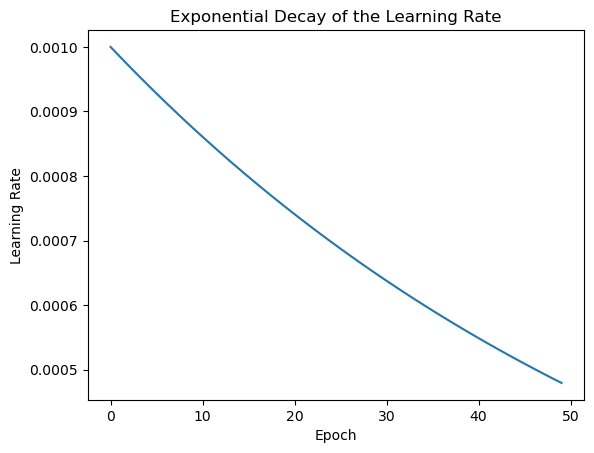

In [33]:


def exponential_decay(epoch,lr_ini=LR,decay_rate=DECAY_RATE,epochs=num_epochs):
    if epoch < epochs*0.001:
        return lr_ini
    else:
        return  lr_ini * np.exp(-decay_rate*epoch)
    
epochs = np.arange(num_epochs)
learning_rates = [exponential_decay(epoch) for epoch in epochs]


plt.plot(epochs, learning_rates, label="Learning Rate")
plt.title("Exponential Decay of the Learning Rate")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.grid(False)
plt.show()  

In [34]:
lr_scheduler = LearningRateScheduler(lambda epoch: exponential_decay(epoch), verbose=1)


optimizer = Adam(learning_rate=LR)
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',  min_delta=1e-2, patience=patience, restore_best_weights=True,verbose=1)
save = save_in + '/Results_weights/Best_weights.weights.h5'
checkpoint_cb=tf.keras.callbacks.ModelCheckpoint(save,save_weights_only=True)

In [35]:
def conv_block_batchnorm(filters,x):
    conv = Conv2D(filters, (3, 3), padding=type_padding)(x)
    conv= BatchNormalization()(conv)
    conv = Activation(f_activation)(conv)
    conv = Conv2D(filters, (3, 3), padding=type_padding)(conv)
    conv= BatchNormalization()(conv)
    conv = Activation(f_activation)(conv)
    return conv
    
def conv_block(filters,x):
    conv = Conv2D(filters, (3, 3), activation=f_activation, padding=type_padding)(x)
    conv = Conv2D(filters, (3, 3), activation=f_activation, padding=type_padding)(conv)
    return conv    

def encoder(x,filters):
    conv = conv_block_batchnorm(filters,x)
    downsample = MaxPooling2D((2,2))(conv)
    return conv,downsample

def biLSTM(x,units,prefix_name):
    B,h,w,c=x.shape
    # Reshape (B, H, W, C) -> (B, W, H*C) for column-wise LSTM
  
    x_seq = Lambda(lambda xx: tf.reshape(xx, (tf.shape(xx)[0], tf.shape(xx)[2], tf.shape(xx)[1] * tf.shape(xx)[3])))(x)
    x_bilstm = layers.Bidirectional(layers.LSTM(units, return_sequences=True,name=f"{prefix_name}_bilstm"))(x_seq) 
    x_dense = layers.TimeDistributed(layers.Dense(h * c, activation='relu', name=f'{prefix_name}_dense'),name=f'{prefix_name}_timedist_dense')(x_bilstm)
    #x_dense = layers.Dense(h*c)(x_bilstm)
    output_tensor = layers.Reshape((h,w,c))( x_dense)

    return output_tensor

def decoder(x1,x2,filters,transpose=None):
    if transpose != None:
        conv_up = Conv2DTranspose(filters,(2,2),strides=(2, 2),padding=type_padding)(x1)
    else:
        conv_up = UpSampling2D((2, 2))(x1)
   
    concat=concatenate([conv_up,x2],axis = 3)
    up = conv_block(filters, concat)
    return up

In [36]:
# number_of_filters = [32,64,128,256,512]
# number_of_units = [16,32,64,128]
#https://g.co/gemini/share/40924d157472
def make_model():
    
    image_input = Input((img_height, img_width, channel))
    
    conv1,down_block1 = encoder (image_input, number_of_filters[0])
    biconv1=biLSTM(conv1,units[0],1)
    
    conv2,down_block2 = encoder (down_block1 , number_of_filters[1])
    biconv2=biLSTM(conv2,units[1],2)
    
    conv3,down_block3 = encoder (down_block2 , number_of_filters[2])
    biconv3=biLSTM(conv3,units[2],3)
    
    conv4,down_block4 = encoder (down_block3 , number_of_filters[3])
    biconv4=biLSTM(conv4,units[3],4)

    conv5 = conv_block(number_of_filters[4],down_block4)
   
    print('conv5',conv5)
    print('biconv4',biconv4)
    
    up6=decoder(conv5,biconv4,number_of_filters[3],transpose='yes')
    up7=decoder(up6,biconv3,number_of_filters[2],transpose='yes')
    up8=decoder(up7,biconv2,number_of_filters[1],transpose='yes')
    up9=decoder(up8,biconv1,number_of_filters[0],transpose='yes')

    flows_out = Conv2D(4, (1, 1), activation=f_activation_last,name='flows_output',padding="same")(up9)

    # construct model
    model =  keras.Model(inputs=image_input, outputs=[flows_out],name= model_name)
    
    model.summary()

    model.compile(optimizer=optimizer, 
              loss = 'mean_squared_error',
              
              metrics= ['mae'] )

    return model  

In [37]:
M=make_model()

conv5 <KerasTensor shape=(None, 4, 16, 512), dtype=float32, sparse=False, ragged=False, name=keras_tensor_54>
biconv4 <KerasTensor shape=(None, 8, 32, 256), dtype=float32, sparse=False, ragged=False, name=keras_tensor_52>


Model: "Unet-LSTM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 256,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 256,   │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 256,   │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 64, 256,   │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 256,   │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 256,   │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 64, 256,   │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 128,   │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 128,   │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 128,   │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 32, 128,   │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 128,   │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 128,   │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 32, 128,   │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 16, 64,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 64,    │        512 │ conv2d_4[0][0]  

 Total params: 12,862,852 (49.07 MB)

 Trainable params: 12,860,932 (49.06 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [38]:
print("Starting trainig")

history = M.fit(train_ds,epochs=num_epochs,validation_data = valid_ds,callbacks=[early_stopping,checkpoint_cb])
callbacks = [lr_scheduler,tf.keras.callbacks.ModelCheckpoint("Unet.keras",save_best_only=True)]
M.save('Completed_Model_fourdecoders.h5')

Starting trainig
Epoch 1/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 44s 237ms/step - loss: 0.0144 - mae: 0.0800 - val_loss: 0.0114 - val_mae: 0.0716
Epoch 2/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 32s 232ms/step - loss: 0.0010 - mae: 0.0202 - val_loss: 0.0082 - val_mae: 0.0594
Epoch 3/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 33s 236ms/step - loss: 2.8760e-04 - mae: 0.0105 - val_loss: 0.0035 - val_mae: 0.0348
Epoch 4/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 33s 235ms/step - loss: 1.9457e-04 - mae: 0.0084 - val_loss: 6.5590e-04 - val_mae: 0.0138
Epoch 5/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 32s 229ms/step - loss: 1.4090e-04 - mae: 0.0072 - val_loss: 2.6793e-04 - val_mae: 0.0110
Epoch 6/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 33s 235ms/step - loss: 1.6565e-04 - mae: 0.0080 - val_loss: 1.7066e-04 - val_mae: 0.0074
Epoch 7/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 32s 231ms/step - loss: 1.0550e-04 - mae: 0.0063 - val_loss: 1.5883e-04 - val_mae: 0.0080
Epoch 8/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 32s 232ms/step - loss: 8.4889e-05 - mae: 0.0057 - val_loss: 

In [39]:
results = M.evaluate(test_ds) 
print("Evaluation results:")
for name, value in zip(M.metrics_names, results):
    print(f"{name}: {value:.4f}")

30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 6.7842e-04 - mae: 0.0139
Evaluation results:
loss: 0.0006
compile_metrics: 0.0137


In [40]:
xtrue=[]
ytrue=[]
for x,y in test_ds:
    xtrue.append(x.numpy())
    ytrue.append(y.numpy())
ypred = list()    
for i in range(len(ytrue)):    
    ypred.append(M.predict(xtrue[i]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━

In [41]:
def plotting():
    N = random.randint(0, len(xtrue)-1)
    M = random.randint(0, nbatch-1)
    titles = [ 'P pred', 'P true','V pred', 'V true','Vx pred', 'Vx true','Vy pred', 'Vy true']
    fig, axes = plt.subplots(4, 3, figsize=(16, 10))
    
    error=[]
    for i in range(4):
            error.append(np.abs(ytrue[M][N][:,:,i]- ypred[M][N][:,:,i]))

            axes[i,0].imshow(ypred[M][N][:,:,i], cmap='gray')
            axes[i, 0].set_title(titles[2*i])
            axes[i, 0].axis('off')

            axes[i,1].imshow(ytrue[M][N][:,:,i], cmap='gray')
            axes[i, 1].set_title(titles[2*i+1])
            axes[i, 1].axis('off')

            e=axes[i,2].imshow(error[0], cmap='turbo')
            axes[i, 2].set_title('Absolute Error')
            axes[i, 2].axis('off')
            plt.colorbar(e, ax=axes[i,2], fraction=0.046)

    for ax in axes.flat:
        ax.axis('off')

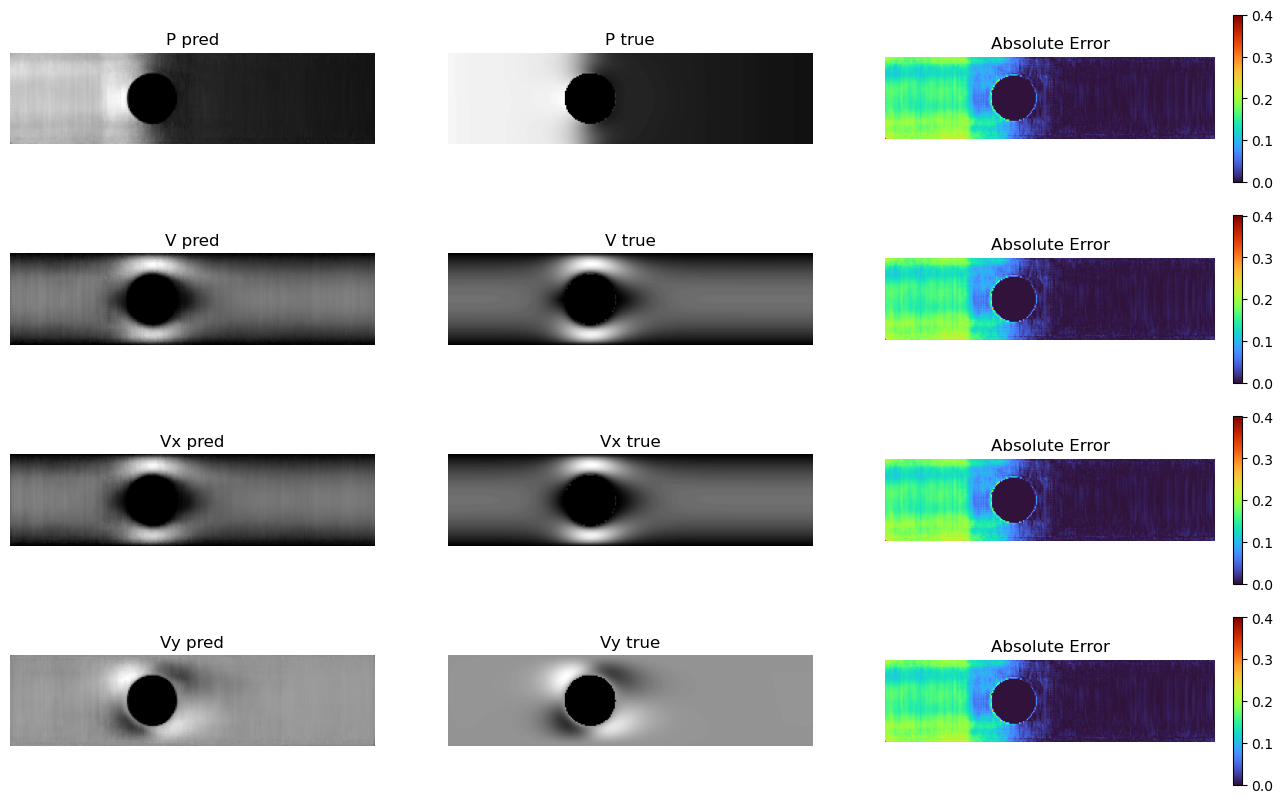

In [48]:
plotting()

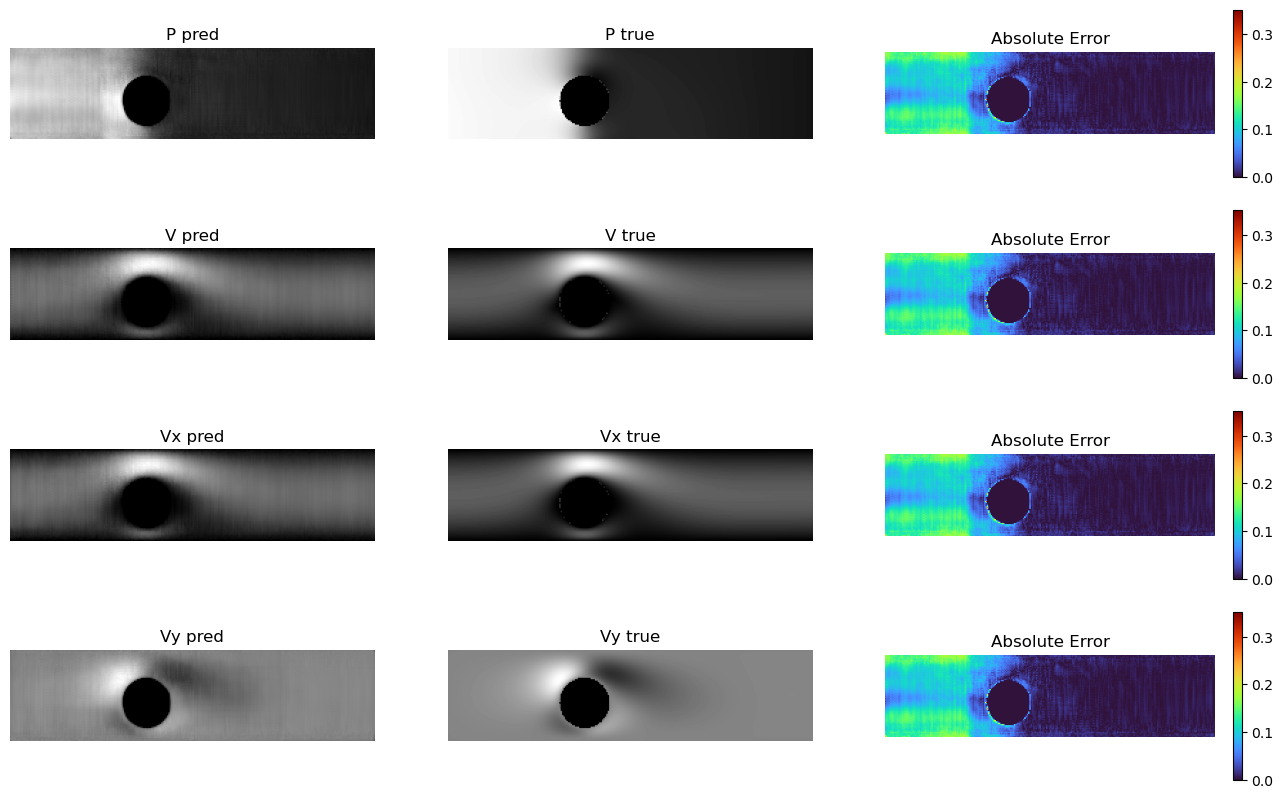

In [53]:
plotting()

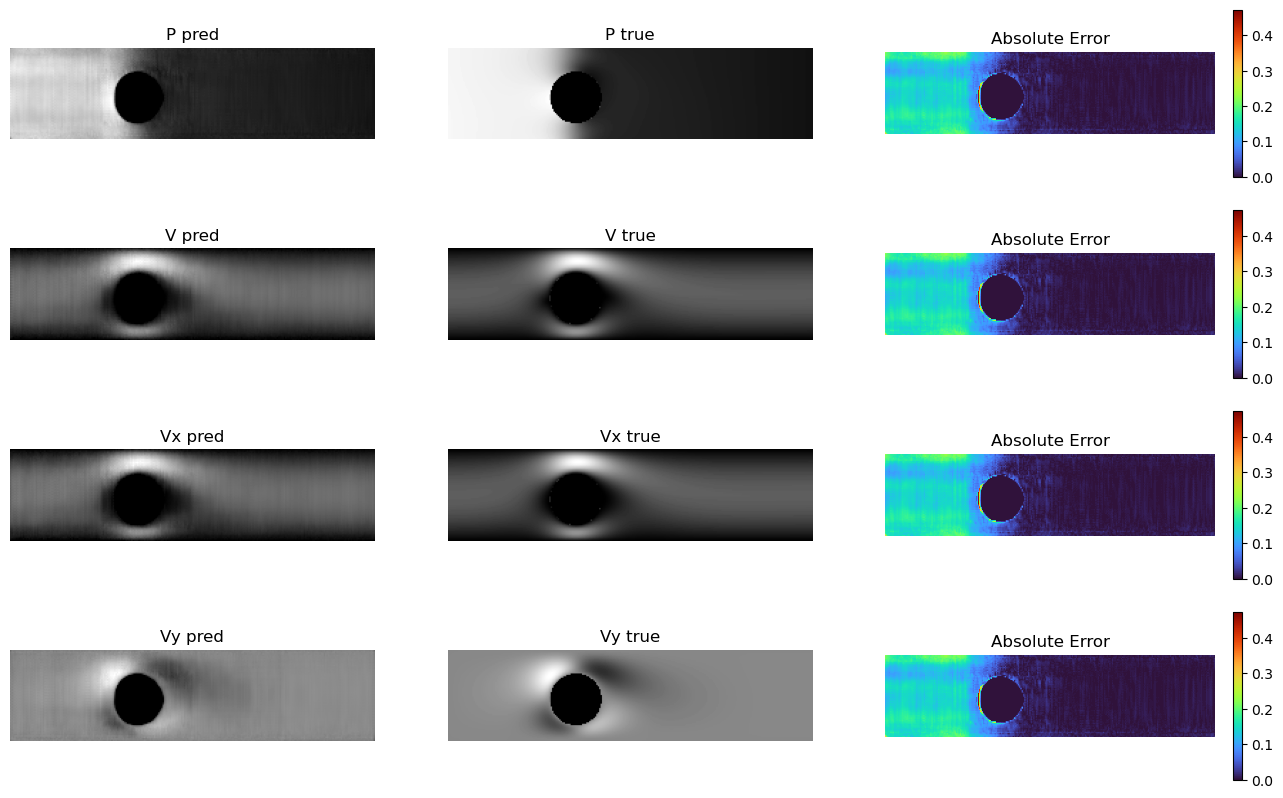

In [60]:
plotting()

In [61]:
# Recolectar predicciones
y_preds = []
y_trues = []

for x_batch, y_batch in test_ds:
    y_pred = M.predict(x_batch)
    y_preds.append(y_pred)
    y_trues.append(y_batch)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━

2025-06-09 15:32:22.726938: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [62]:
y_preds = np.concatenate(y_preds, axis=0)  # (N, H, W, 4)
y_trues = np.concatenate(y_trues, axis=0)

In [63]:
# Calcular MSE y MAE por canal
from sklearn.metrics import mean_squared_error, mean_absolute_error
for i, var in enumerate(["p", "v", "vx", "vy"]):
    mse = mean_squared_error(y_trues[..., i].ravel(), y_preds[..., i].ravel())
    mae = mean_absolute_error(y_trues[..., i].ravel(), y_preds[..., i].ravel())
    print(f"{var}: MSE = {mse:.4f}, MAE = {mae:.4f}")

p: MSE = 0.0019, MAE = 0.0240
v: MSE = 0.0002, MAE = 0.0110
vx: MSE = 0.0002, MAE = 0.0107
vy: MSE = 0.0002, MAE = 0.0090


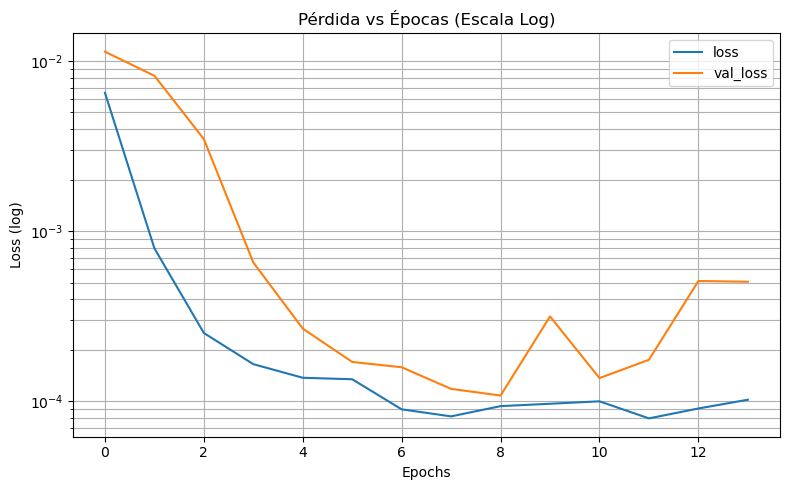

In [64]:

pd.DataFrame(history.history)[['loss', 'val_loss']].plot(figsize=(8, 5))
plt.yscale('log')       # Escala logarítmica para el eje Y
plt.grid(True, which='both')  # Mostrar grid tanto en escala mayor como menor
plt.title("Pérdida vs Épocas (Escala Log)")
plt.xlabel("Epochs")
plt.ylabel("Loss (log)")
plt.tight_layout()
plt.show()


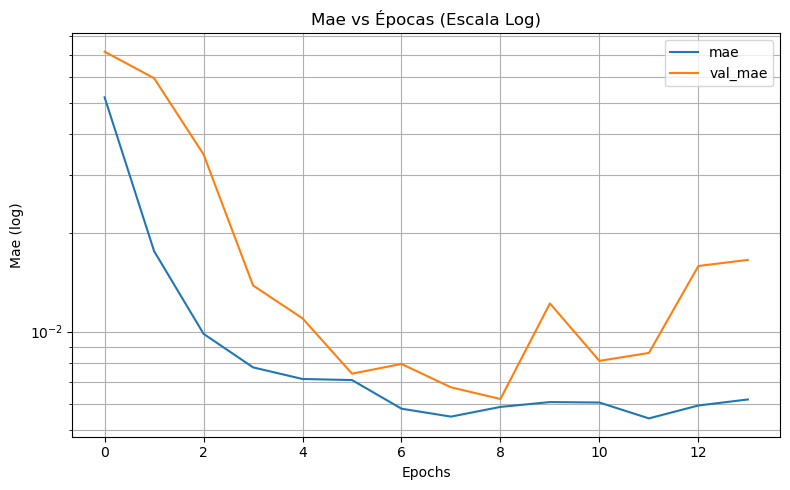

In [65]:

pd.DataFrame(history.history)[['mae', 'val_mae']].plot(figsize=(8, 5))
plt.yscale('log')       # Escala logarítmica para el eje Y
plt.grid(True, which='both')  # Mostrar grid tanto en escala mayor como menor
plt.title("Mae vs Épocas (Escala Log)")
plt.xlabel("Epochs")
plt.ylabel("Mae (log)")
plt.tight_layout()
plt.show()